<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [2]:
## Write your code here

# Step 1: Display basic info about columns and data types
print("🔹 DataFrame Info:")
print(df.info())

# Step 2: Display column names
print("\n🔹 Column Names:")
print(df.columns.tolist())

# Step 3: Display dataset shape (rows, columns)
print("\n🔹 Dataset Shape:")
print(df.shape)

# Step 4: Display summary statistics for numerical columns
print("\n🔹 Summary Statistics (Numerical):")
print(df.describe())

# Step 5: Display summary statistics for categorical columns
print("\n🔹 Summary Statistics (Categorical):")
print(df.describe(include=['object']))


🔹 DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB
None

🔹 Column Names:
['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check', 'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline', 'TechDoc', 'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'PurchaseInfluence', 'BuyNewTool', 'BuildvsBuy', 'TechEndorse', 'Country', 'Currency', 'CompTotal', 'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'LanguageAdmired', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'DatabaseAdmired', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'PlatformAdmired', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'WebframeAdmired', 'EmbeddedHaveWorkedWith', 'EmbeddedWantToWorkWith', 'EmbeddedAdmired', 'MiscTechHaveWorkedWith', 'MiscTechWantToWorkWith', 'MiscTechAdmired', 'ToolsTechHaveWorkedWith', 'ToolsTechWantToWorkWith

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [3]:
## Write your code here



# Step 1: Check missing values
print("🔹 Missing Values per Column:")
print(df.isnull().sum().sort_values(ascending=False))

# Step 2: Handling Missing Values

# For numerical columns → fill with median (robust to outliers)
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# For categorical columns → fill with mode (most frequent value)
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Step 3: Verify again
print("\n✅ Missing Values After Imputation:")
print(df.isnull().sum().sum()) 


🔹 Missing Values per Column:
AINextMuch less integrated    64289
AINextLess integrated         63082
AINextNo change               52939
AINextMuch more integrated    51999
EmbeddedAdmired               48704
                              ...  
MainBranch                        0
Check                             0
Employment                        0
Age                               0
ResponseId                        0
Length: 114, dtype: int64


C:\Users\praka\AppData\Local\Temp\ipykernel_28000\3830230564.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)



✅ Missing Values After Imputation:
0


### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [4]:
## Write your code here



# Employment distribution
print("🔹 Employment Distribution:")
print(df['Employment'].value_counts(dropna=False, normalize=True) * 100)
print("\n")

# Job Satisfaction distribution
print("🔹 JobSat Distribution:")
print(df['JobSat'].value_counts(dropna=False, normalize=True) * 100)
print("\n")

# Years of Professional Coding Experience
print("🔹 YearsCodePro Distribution:")
print(df['YearsCodePro'].value_counts(dropna=False, normalize=True) * 100)


🔹 Employment Distribution:
Employment
Employed, full-time                                                                                                                                  59.661965
Independent contractor, freelancer, or self-employed                                                                                                  7.405596
Student, full-time                                                                                                                                    7.196235
Employed, full-time;Independent contractor, freelancer, or self-employed                                                                              5.435763
Not employed, but looking for work                                                                                                                    3.577487
                                                                                                                                                       ...    
Employed

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


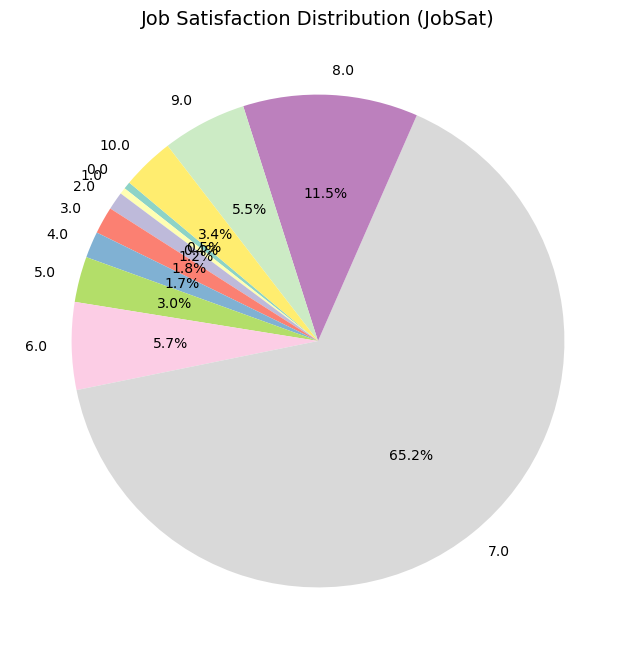

In [5]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Count values
job_sat_counts = df['JobSat'].value_counts().sort_index()

# Generate colors using a colormap
colors = cm.Set3(np.linspace(0, 1, len(job_sat_counts)))

# Pie chart
plt.figure(figsize=(8,8))
plt.pie(job_sat_counts, labels=job_sat_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=colors)
plt.title("Job Satisfaction Distribution (JobSat)", fontsize=14)
plt.show()


### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


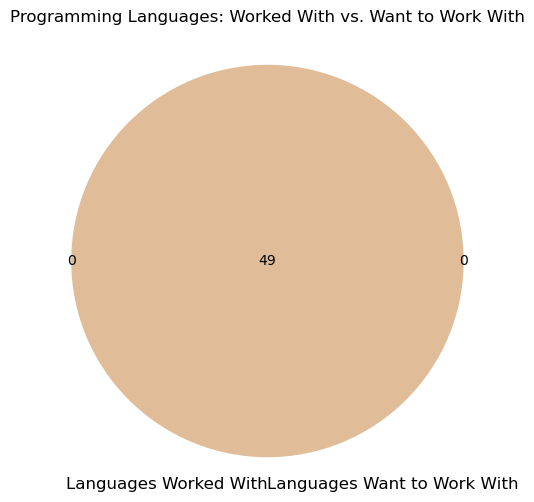

In [6]:
!pip install matplotlib-venn

from matplotlib_venn import venn2

# Split and flatten the responses (LanguageHaveWorkedWith & LanguageWantToWorkWith are usually semicolon-separated)
worked = set(lang.strip() for sublist in df['LanguageHaveWorkedWith'].dropna().str.split(';') for lang in sublist)
want   = set(lang.strip() for sublist in df['LanguageWantToWorkWith'].dropna().str.split(';') for lang in sublist)

# Plot Venn diagram
plt.figure(figsize=(8,6))
venn2([worked, want], set_labels=("Languages Worked With", "Languages Want to Work With"))
plt.title("Programming Languages: Worked With vs. Want to Work With")
plt.show()


In [9]:

# Explode the "LanguageHaveWorkedWith" column
df_exploded = df['LanguageHaveWorkedWith'].dropna().str.split(';').explode().to_frame(name='LanguageList')

# Explode the "LanguageWantToWorkWith" column
df_exploded_want = df['LanguageWantToWorkWith'].dropna().str.split(';').explode().to_frame(name='LanguageWantList')

# Calculate value counts for 'LanguageList' (languages worked with)
have_counts = df_exploded['LanguageList'].value_counts().reset_index()
have_counts.columns = ['LanguageList', 'Count']
have_counts['Category'] = 'Worked With'

# Calculate value counts for 'LanguageWantList' (languages want to work with)
want_counts = df_exploded_want['LanguageWantList'].value_counts().reset_index()
want_counts.columns = ['LanguageWantList', 'Count']
want_counts['Category'] = 'Want to Work With'

# Display results
print("Value counts for languages worked with:")
display(have_counts.head())
print("\nShape of have_counts:", have_counts.shape)

print("\nValue counts for languages want to work with:")
display(want_counts.head())
print("\nShape of want_counts:", want_counts.shape)


Value counts for languages worked with:


,LanguageList,Count,Category
0,JavaScript,43184,Worked With
1,HTML/CSS,37508,Worked With
2,Python,30719,Worked With
3,SQL,30682,Worked With
4,TypeScript,28842,Worked With



Shape of have_counts: (49, 3)

Value counts for languages want to work with:


,LanguageWantList,Count,Category
0,Python,34732,Want to Work With
1,JavaScript,23774,Want to Work With
2,SQL,22400,Want to Work With
3,HTML/CSS,20721,Want to Work With
4,TypeScript,20239,Want to Work With



Shape of want_counts: (49, 3)


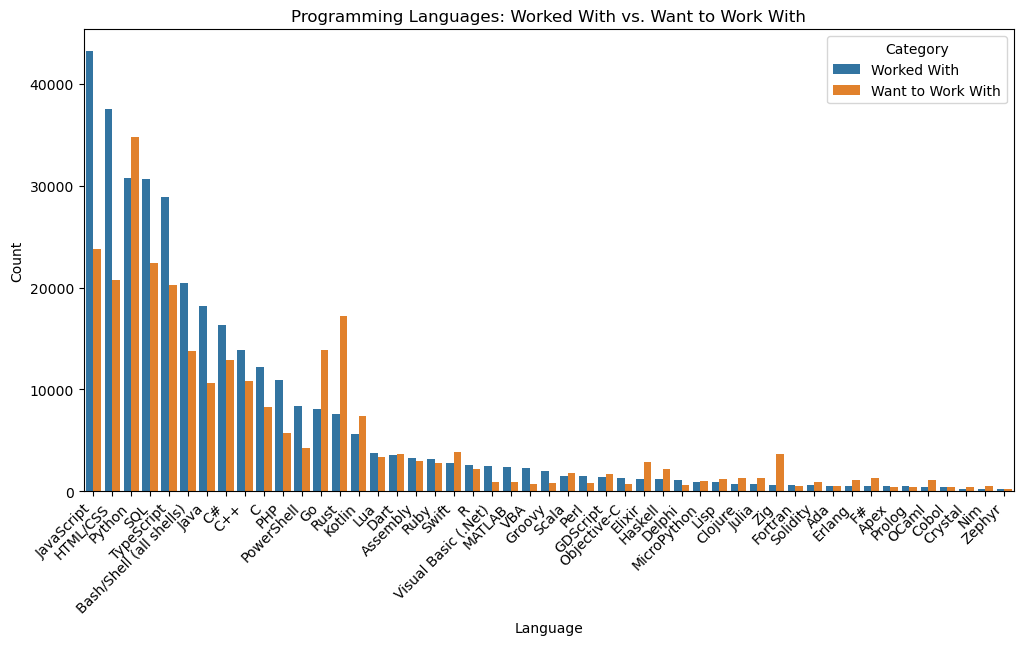

In [13]:
# Rename columns so both DataFrames have the same structure
have_counts_renamed = have_counts.rename(columns={"LanguageList": "Language"})
want_counts_renamed = want_counts.rename(columns={"LanguageWantList": "Language"})

# Combine into one DataFrame
lang_compare = pd.concat([have_counts_renamed, want_counts_renamed])

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(data=lang_compare, x="Language", y="Count", hue="Category")
plt.xticks(rotation=45, ha="right")
plt.title("Programming Languages: Worked With vs. Want to Work With")
plt.show()



### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


Normalized Remote Work Distribution by Top 5 Countries:


RemoteWork,"Hybrid (some remote, some in-person)",In-person,Remote
Country,,,
Brazil,0.341818,0.138909,0.519273
Canada,0.461027,0.107890,0.431084
France,0.636967,0.169194,0.193839
Germany,0.626238,0.130786,0.242976
India,0.541243,0.257150,0.201607
Netherlands,0.709455,0.165631,0.124914
Poland,0.447197,0.087353,0.465450
Ukraine,0.309880,0.041542,0.648578
United Kingdom of Great Britain and Northern Ireland,0.547457,0.095223,0.357320


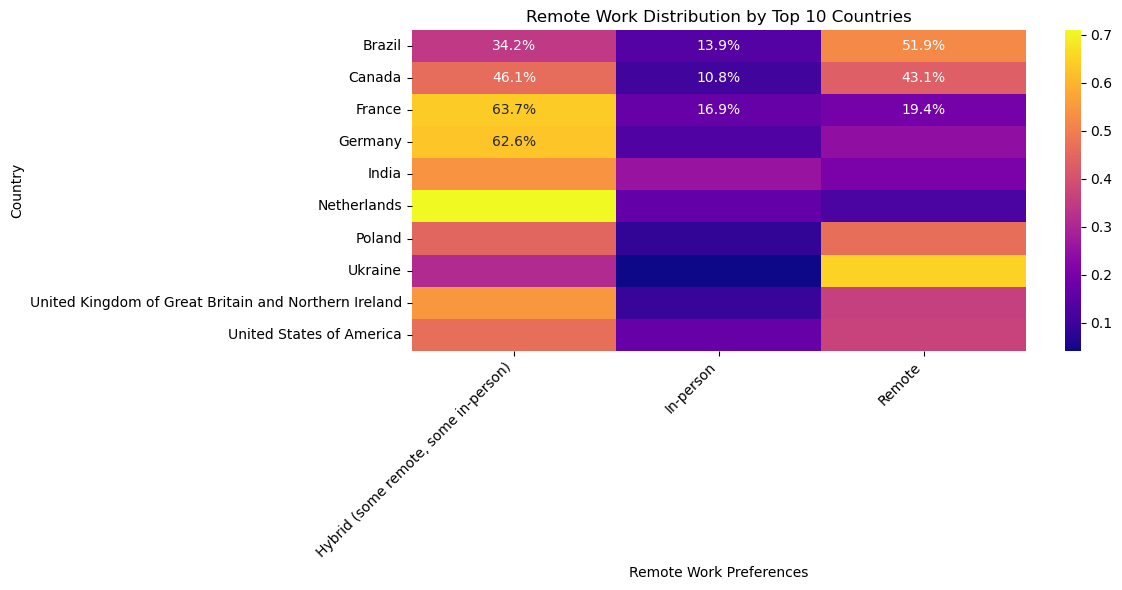

In [21]:
## Write your code here

# Select the top 10 countries based on the total number of responses
top_countries = df['Country'].value_counts().nlargest(10).index.tolist()

# Filter the DataFrame to include only the rows corresponding to these top 10 countries
df_top_countries_remote = df[df['Country'].isin(top_countries)]

# Create a cross-tabulation of 'Country' and 'RemoteWork' for the top countries
cross_tab_country_remote = pd.crosstab(df_top_countries_remote['Country'], df_top_countries_remote['RemoteWork'])

# Normalize the cross-tabulation to show percentages
cross_tab_country_remote_normalized = cross_tab_country_remote.apply(lambda r: r/r.sum(), axis=1)

# Display the normalized cross-tabulation
print("Normalized Remote Work Distribution by Top 5 Countries:")
display(cross_tab_country_remote_normalized)

# Create a heatmap of the normalized data
plt.figure(figsize=(12, 6))
sns.heatmap(cross_tab_country_remote_normalized, annot=True, fmt=".1%", cmap="plasma")
plt.xlabel('Remote Work Preferences')
plt.ylabel('Country')
plt.title('Remote Work Distribution by Top 10 Countries')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


In [23]:
## Write your code here

import numpy as np
from scipy.stats import pearsonr, spearmanr

# Clean and convert YearsCodePro to numeric
def convert_years(val):
    if val == "Less than 1 year":
        return 0.5
    elif val == "More than 50 years":
        return 51
    else:
        try:
            return float(val)
        except:
            return np.nan

df["YearsCodeProNumeric"] = df["YearsCodePro"].apply(convert_years)

# Drop rows with missing values in JobSat or YearsCodePro
df_corr = df[["JobSat", "YearsCodeProNumeric"]].dropna()

# Pearson correlation
pearson_corr, pearson_p = pearsonr(df_corr["JobSat"], df_corr["YearsCodeProNumeric"])

# Spearman correlation
spearman_corr, spearman_p = spearmanr(df_corr["JobSat"], df_corr["YearsCodeProNumeric"])

print(f"Pearson Correlation: {pearson_corr:.3f} (p={pearson_p:.3e})")
print(f"Spearman Correlation: {spearman_corr:.3f} (p={spearman_p:.3e})")

Pearson Correlation: 0.066 (p=9.013e-64)
Spearman Correlation: 0.105 (p=2.909e-159)


### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


Employment                                       Employed, full-time  \
EdLevel                                                                
Associate degree (A.A., A.S., etc.)                             1059   
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                   19322   
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                11011   
Primary/elementary school                                        160   
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                  2073   

Employment                                       Employed, full-time;Employed, part-time  \
EdLevel                                                                                    
Associate degree (A.A., A.S., etc.)                                                    9   
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                         106   
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       61   
Primary/elementary school          

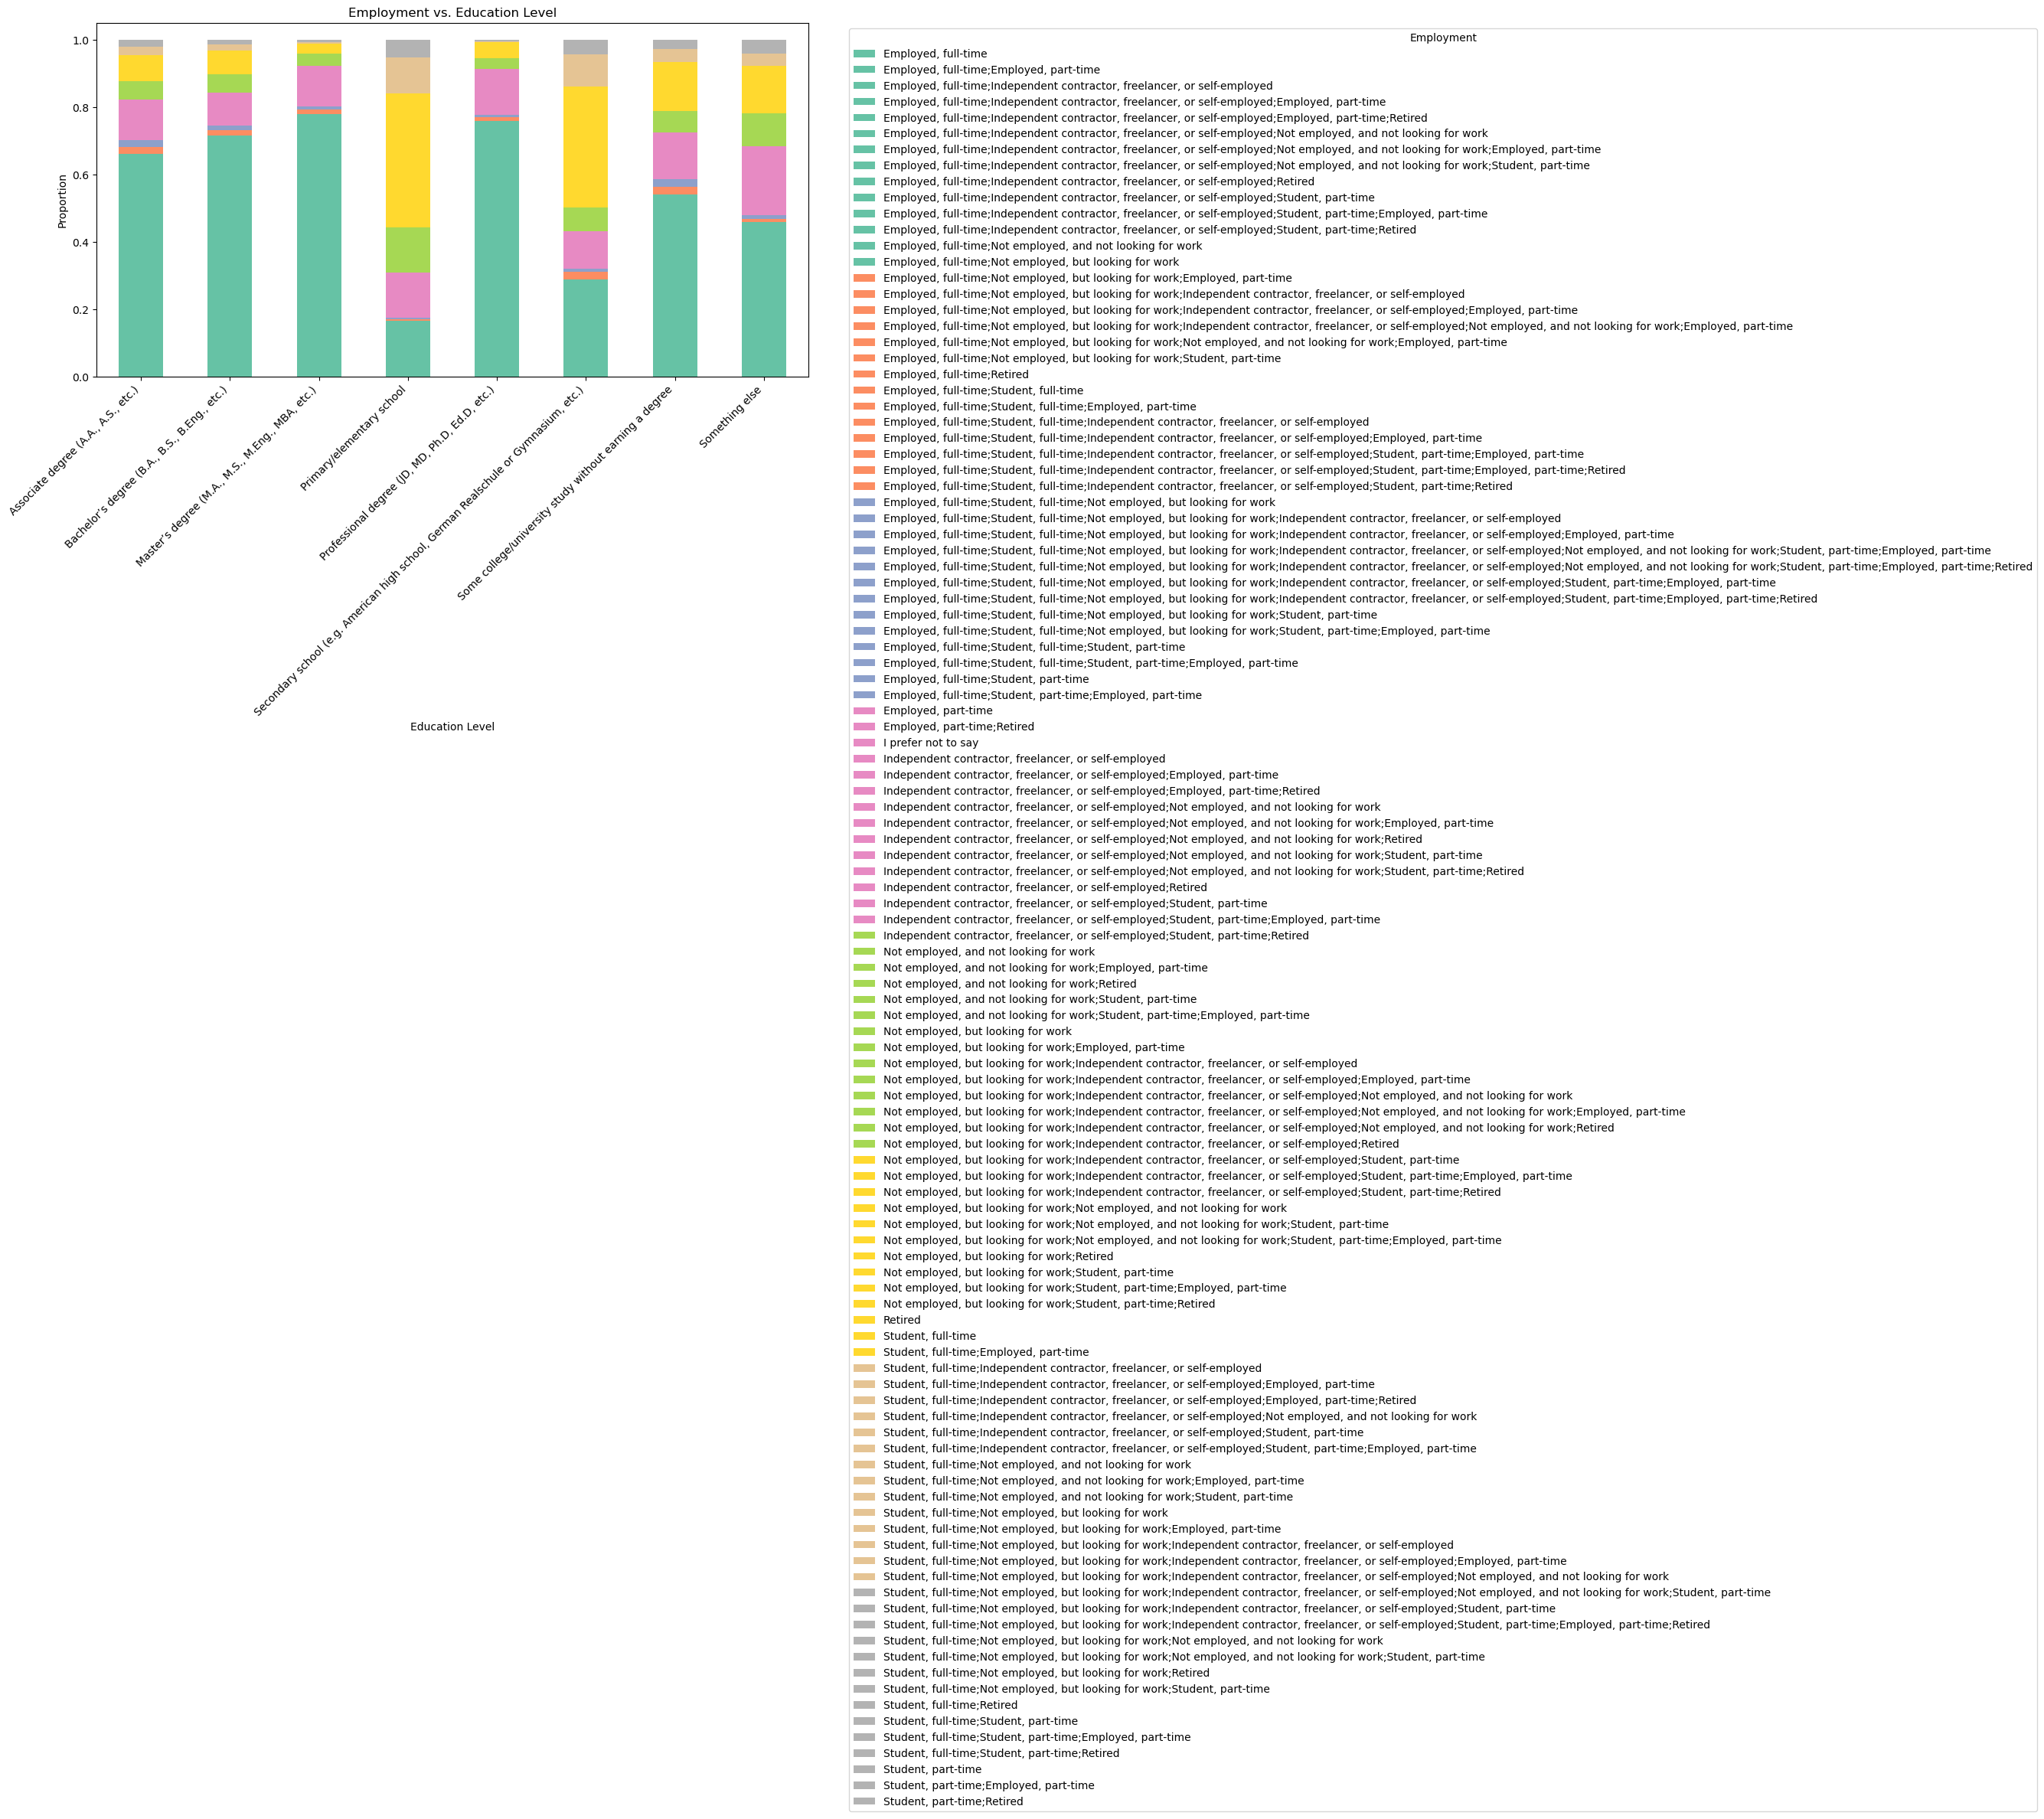

In [25]:
## Write your code here

cross_tab = pd.crosstab(df['EdLevel'], df['Employment'])

# Normalize by row to show proportions (optional)
cross_tab_norm = cross_tab.div(cross_tab.sum(axis=1), axis=0)

# Display first few rows
print(cross_tab.head())
print("\nNormalized cross-tab:")
print(cross_tab_norm.head())

# Plot stacked bar chart
cross_tab_norm.plot(kind='bar', stacked=True, figsize=(12,6), colormap="Set2")

plt.title("Employment vs. Education Level")
plt.ylabel("Proportion")
plt.xlabel("Education Level")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Employment", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [ ]:
## Write your code here

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
